In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
# import plotly.express as px

from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
# import geodatasets

from functools import reduce
from scipy.spatial.distance import cdist

In [2]:
# change path to parent dir
parent = os.path.dirname(os.getcwd())

os.chdir(parent)

In [3]:
os.getcwd()

'c:\\Users\\2702471O\\OneDrive - University of Glasgow\\03Price modelling\\07project'

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# 1. Read data

In [5]:
listings = pd.read_csv('data/02_intermediate/listings_prep.csv')

C:\Users\2702471O\AppData\Local\Temp\ipykernel_31000\1421078732.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv('data/02_intermediate/listings_prep.csv')


In [6]:
listings.columns

Index(['Unnamed: 0', 'listing_change_id', 'listing_id', 'date', 'change_type',
       'uprn', 'displayable_address', 'postcode', 'pcd', 'property_number',
       'street', 'town', 'county', 'category', 'transaction_type',
       'property_type', 'bedrooms', 'bathrooms', 'receptions', 'floors',
       'floor_area', 'tenure', 'price', 'rent_frequency',
       'summary_description', 'bullets', 'detailed_description', 'new_home',
       'listing_status', 'buyer_incentives', 'shared_accommodation', 'auction',
       'latitude', 'longitude', 'nspl_local_authority', 'nspl_region',
       'nspl_country', 'image_count', 'image_list', 'plan_count', 'plan_list',
       'year', 'month', 'is_auction', 'is_shareo'],
      dtype='object')

In [7]:
listings[(listings['price']<=1500000)&(listings['price']>=30000)].shape

(230608, 45)

In [ ]:
EPC_dfs = []

for chunk in pd.read_csv('data/02_intermediate/epc.csv.gz', chunksize=10000):
    EPC_dfs.append(chunk)

epcs = pd.concat(EPC_dfs)

C:\Users\2702471O\AppData\Local\Temp\ipykernel_20292\1156839530.py:3: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('data/02_intermediate/epc.csv.gz', chunksize=10000):
C:\Users\2702471O\AppData\Local\Temp\ipykernel_20292\1156839530.py:3: DtypeWarning: Columns (37) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('data/02_intermediate/epc.csv.gz', chunksize=10000):
C:\Users\2702471O\AppData\Local\Temp\ipykernel_20292\1156839530.py:3: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('data/02_intermediate/epc.csv.gz', chunksize=10000):
C:\Users\2702471O\AppData\Local\Temp\ipykernel_20292\1156839530.py:3: DtypeWarning: Columns (3,51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('data/02_intermediate/epc.csv.gz', chunksize=10

In [ ]:
# 2011 Census
dir = 'data/01_raw/NSPL'

geos = os.listdir(dir)

dfs = []

# load files
for geo in geos:
    path = dir + '\\' + geo

    for chunk in pd.read_csv(path, chunksize=10000):
        dfs.append(chunk)

geo_lookup = pd.concat(dfs)

# 2. Data linkage

In [ ]:
listing_epc = listings.join(epcs.set_index('UPRN'), on='uprn', how='inner')

In [ ]:
listing_epc['listing_id'].nunique()

226291

(array([1.47043e+05, 6.59750e+04, 1.10710e+04, 1.77000e+03, 0.00000e+00,
        3.62000e+02, 4.80000e+01, 1.20000e+01, 9.00000e+00, 1.00000e+00]),
 array([1. , 1.8, 2.6, 3.4, 4.2, 5. , 5.8, 6.6, 7.4, 8.2, 9. ]),
 <BarContainer object of 10 artists>)

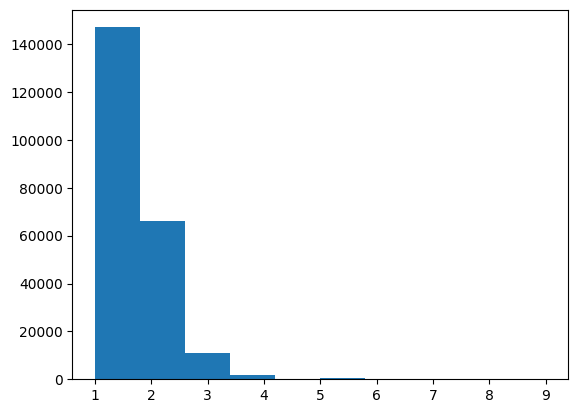

In [ ]:
plt.hist(listing_epc.groupby('listing_id').size())

In [ ]:
listing_epc.groupby('listing_id').size().value_counts()

1    147043
2     65975
3     11071
4      1770
5       362
6        48
7        12
8         9
9         1
Name: count, dtype: int64

# 3. Deduplication

In [ ]:
listing_epc['date'] = pd.to_datetime(listing_epc['date'],format='%Y-%m-%d')
listing_epc['LODGEMENT_DATE'] = pd.to_datetime(listing_epc['LODGEMENT_DATE'],format='%Y-%m-%d')
listing_epc['INSPECTION_DATE'] = pd.to_datetime(listing_epc['INSPECTION_DATE'],format='%Y-%m-%d')

## 3.1 Drop invalid epc

- issued more than 10 years ago (use lodgement date)
- issued after sales

In [ ]:
# year gap
listing_epc['year_gap'] = (listing_epc['LODGEMENT_DATE'].dt.year - listing_epc['date'].dt.year)

# date gap
listing_epc['date_gap'] = listing_epc['LODGEMENT_DATE']- listing_epc['date']
listing_epc['date_gap'] = listing_epc['date_gap'].apply(lambda x: x.days)

In [ ]:
# choose EPC lodgement from ten years ago to same date as sales end date
listing_epc_val = listing_epc[(listing_epc['year_gap']>=-10) & (listing_epc['date_gap']<=0)].copy()

In [ ]:
# report number of listings 
listing_epc_val['listing_id'].nunique(), listing_epc_val['listing_id'].nunique()/listing_epc['listing_id'].nunique()

(216601, 0.9571790305403219)

## 3.2 Deduplication

- choose the latest lodgement date

In [ ]:
# sort by lodgement date
listing_epc_val = listing_epc_val.sort_values(by=['listing_id','LODGEMENT_DATE'])

In [ ]:
# deduplicate and keep latest
listing_epc_val_dedu = listing_epc_val.drop_duplicates(subset=['listing_id'],keep='last')

In [ ]:
# report rows and percentage (unique listing)
listing_epc_val_dedu['listing_id'].nunique(), listing_epc_val_dedu['listing_id'].nunique()/listing_epc_val['listing_id'].nunique()

(216601, 1.0)

# 4. Neighbourhood attributes linkage

## 4.1 Read data

In [ ]:
# uprn - lat, lon
uprn_dfs = []

for chunk in pd.read_csv('data/01_raw/osopenuprn_202406.csv', chunksize=10000):
    uprn_dfs.append(chunk)

uprn = pd.concat(uprn_dfs)

In [ ]:
uprn.head()

,UPRN,X_COORDINATE,Y_COORDINATE,LATITUDE,LONGITUDE
0,1,358260.66,172796.5,51.452601,-2.602075
1,26,352967.00,181077.0,51.526633,-2.679361
2,27,352967.00,181077.0,51.526633,-2.679361
3,30,354800.00,180469.0,51.521317,-2.652862
4,31,354796.00,180460.0,51.521236,-2.652918


In [ ]:
# population density
pop_den_lsoa = pd.read_excel('data/01_raw/Popden/lsoa11_mid_2020.xlsx',sheet_name='Mid-2020 Population Density',skiprows=4)

In [ ]:
pop_den_lsoa.head()

,LSOA Code,LSOA Name,Mid-2020 population,Area Sq Km,People per Sq Km
0,E01011949,Hartlepool 009A,1944,0.5189,3746.386587
1,E01011950,Hartlepool 008A,1298,0.1325,9796.226415
2,E01011951,Hartlepool 007A,1208,0.2086,5790.987536
3,E01011952,Hartlepool 002A,1724,0.4641,3714.716656
4,E01011953,Hartlepool 002B,2026,0.8833,2293.671459


In [ ]:
pop_den_lsoa['LA Name'] = pop_den_lsoa['LSOA Name'].apply(lambda x: x[:-5])

In [ ]:
pop_den_lsoa = pop_den_lsoa[pop_den_lsoa['LA Name'].isin(['Bolton','Bury', 'Manchester', 'Oldham', 'Rochdale', 'Salford', 'Stockport', 'Tameside', 'Trafford', 'Wigan'])]

In [ ]:
pop_den_lsoa.shape

(1673, 6)

In [ ]:
# IMD
imd = pd.read_excel('data/01_raw/IMD/IoD2019.xlsx',sheet_name='IoD2019 Domains')

In [ ]:
imd_score = pd.read_csv('data/01_raw/IMD/IMD_score_rank_decile_2019.csv')

In [ ]:
imd.columns = ['LSOAcd', 'LSOAnm', 'LAcd', 'LAnm','IMDrk','IMDde','income_rk','income_de','employ_rk','employ_de','edu_rk','edu_de','health_rk','health_de','crime_rk','crime_de','housing_rk','housing_de','env_rk','env_de']

In [9]:
# accessibility - LSOA level
# read all and append
pt_dir = 'data/01_raw/Accessibility/accessibility_indicators_gb/accessibility'
pt_all = []

for dir in os.listdir(pt_dir):
    if dir == 'descrip_accessibility.csv':
        continue
    else:
        files = glob.glob(pt_dir+'/'+dir+"/*_pt.csv")
        for file in files:
            pt_all.append(pd.read_csv(file))

import functools as ft
pt_df = ft.reduce(lambda left, right: pd.merge(left, right, on=['geo_code','geo_label']), pt_all)

In [10]:
# drop the relative measures columns
cols_to_drop = pt_df.columns[pt_df.columns.str.contains('pct')]

pt_df.drop(cols_to_drop, axis=1, inplace=True)

In [11]:
pt_df.dtypes

geo_code                 object
geo_label                object
employment_15             int64
employment_30             int64
employment_45             int64
employment_60             int64
employment_75             int64
employment_90             int64
employment_105            int64
employment_120            int64
gp_number_15              int64
gp_number_30              int64
gp_number_45              int64
gp_number_60              int64
gp_number_75              int64
gp_number_90              int64
gp_number_105             int64
gp_number_120             int64
nearest_gp              float64
hospitals_15              int64
hospitals_30              int64
hospitals_45              int64
hospitals_60              int64
hospitals_75              int64
hospitals_90              int64
hospitals_105             int64
hospitals_120             int64
nearest_hosp            float64
school_primary_15         int64
school_primary_30         int64
school_primary_45         int64
school_p

In [22]:
pt_df.shape

(41729, 57)

In [12]:
# select GM
GM_lsoa = gpd.read_file('data/01_raw/Shapefile/GM_lsoa.shp')

In [13]:
pt_gm = pt_df.join(GM_lsoa.set_index('code'),on='geo_code',how='inner')

In [14]:
# mean price at lsoa level
lsoa_meanp = listing_epc_val_dedu.groupby(by='lsoa11')['price'].mean().reset_index()

NameError: name 'listing_epc_val_dedu' is not defined

In [15]:
pt_gm_price = pt_gm.join(lsoa_meanp.set_index('lsoa11'),on='geo_code',how='inner')

NameError: name 'lsoa_meanp' is not defined

In [24]:
pt_gm.select_dtypes('number').columns

Index(['employment_15', 'employment_30', 'employment_45', 'employment_60',
       'employment_75', 'employment_90', 'employment_105', 'employment_120',
       'gp_number_15', 'gp_number_30', 'gp_number_45', 'gp_number_60',
       'gp_number_75', 'gp_number_90', 'gp_number_105', 'gp_number_120',
       'nearest_gp', 'hospitals_15', 'hospitals_30', 'hospitals_45',
       'hospitals_60', 'hospitals_75', 'hospitals_90', 'hospitals_105',
       'hospitals_120', 'nearest_hosp', 'school_primary_15',
       'school_primary_30', 'school_primary_45', 'school_primary_60',
       'school_primary_75', 'school_primary_90', 'school_primary_105',
       'school_primary_120', 'school_secondary_15', 'school_secondary_30',
       'school_secondary_45', 'school_secondary_60', 'school_secondary_75',
       'school_secondary_90', 'school_secondary_105', 'school_secondary_120',
       'nearest_primary', 'nearest_secondary', 'supermarket_15',
       'supermarket_30', 'supermarket_45', 'supermarket_60', 'super

<Axes: >

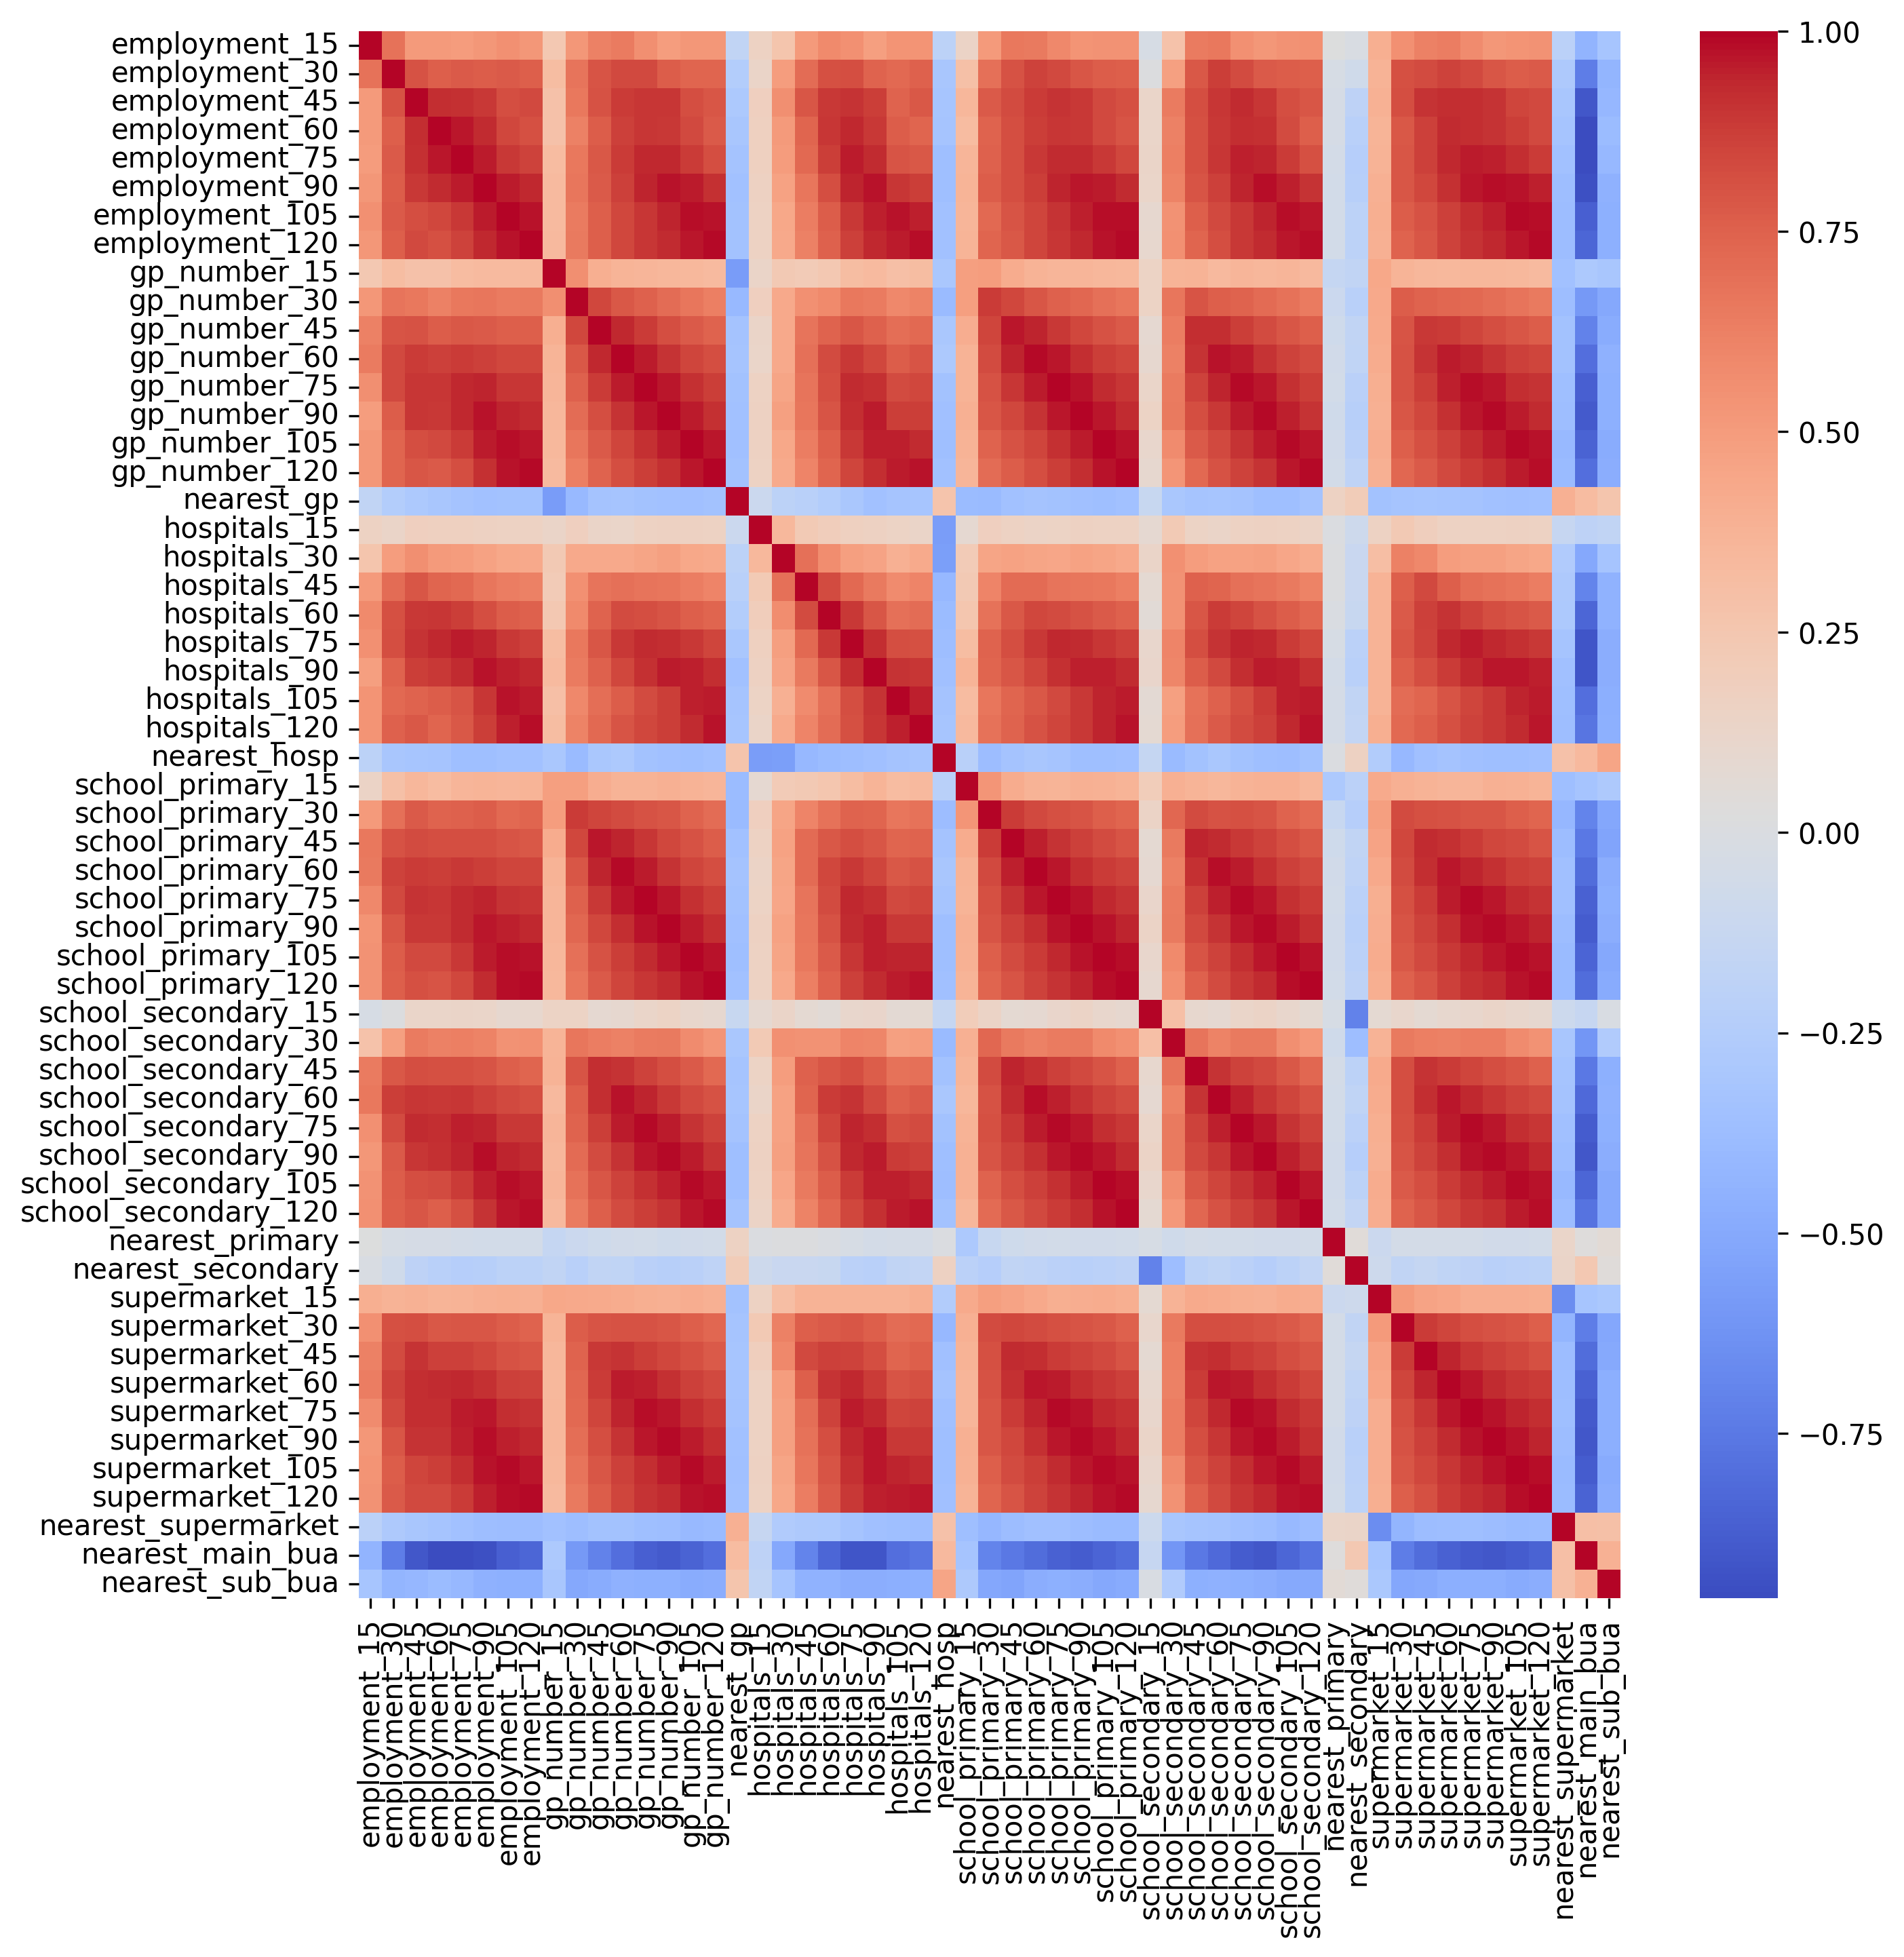

In [29]:
corr = pt_gm.select_dtypes('number').drop(['Shape_Leng', 'Shape_Area'],axis=1).corr()

fig = plt.figure(figsize=(10, 10), dpi=300)

sns.heatmap(corr,cmap=sns.color_palette("coolwarm", as_cmap=True),xticklabels=True, yticklabels=True)

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [18]:
pt_gm.select_dtypes('number').drop(['Shape_Leng', 'Shape_Area'],axis=1).columns

Index(['employment_15', 'employment_30', 'employment_45', 'employment_60',
       'employment_75', 'employment_90', 'employment_105', 'employment_120',
       'gp_number_15', 'gp_number_30', 'gp_number_45', 'gp_number_60',
       'gp_number_75', 'gp_number_90', 'gp_number_105', 'gp_number_120',
       'nearest_gp', 'hospitals_15', 'hospitals_30', 'hospitals_45',
       'hospitals_60', 'hospitals_75', 'hospitals_90', 'hospitals_105',
       'hospitals_120', 'nearest_hosp', 'school_primary_15',
       'school_primary_30', 'school_primary_45', 'school_primary_60',
       'school_primary_75', 'school_primary_90', 'school_primary_105',
       'school_primary_120', 'school_secondary_15', 'school_secondary_30',
       'school_secondary_45', 'school_secondary_60', 'school_secondary_75',
       'school_secondary_90', 'school_secondary_105', 'school_secondary_120',
       'nearest_primary', 'nearest_secondary', 'supermarket_15',
       'supermarket_30', 'supermarket_45', 'supermarket_60', 'super

In [21]:
pt_gm.shape

(1673, 63)

In [19]:
# Fit to data and predict using pipelined scaling, GNB and PCA
std_pca = make_pipeline(StandardScaler(), PCA(n_components=2))
pt_pca = std_pca.fit_transform(pt_gm.select_dtypes('number').drop(['Shape_Leng', 'Shape_Area'],axis=1))

In [20]:
pt_pca.shape

(1673, 2)

In [ ]:
total_var = std_pca[1].explained_variance_ratio_.sum() * 100

In [ ]:
std_pca[1].explained_variance_ratio_

array([0.68545938, 0.0491664 ])

In [45]:
total_var

np.float64(73.46257727285371)

In [30]:
pca = std_pca.named_steps["pca"]
features = (
    pt_gm
    .select_dtypes("number")
    .drop(["Shape_Leng", "Shape_Area"], axis=1)
    .columns
)

In [31]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

corr_df = pd.DataFrame(
    loadings,
    index=features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

corr_df

,PC1,PC2
employment_15,0.605500,-0.015040
employment_30,0.847248,-0.044500
employment_45,0.919757,-0.033135
employment_60,0.914644,-0.062596
employment_75,0.942502,-0.064132
employment_90,0.965385,-0.120787
employment_105,0.949263,-0.175689
employment_120,0.940117,-0.166444
gp_number_15,0.404933,0.557361
gp_number_30,0.773841,0.365799


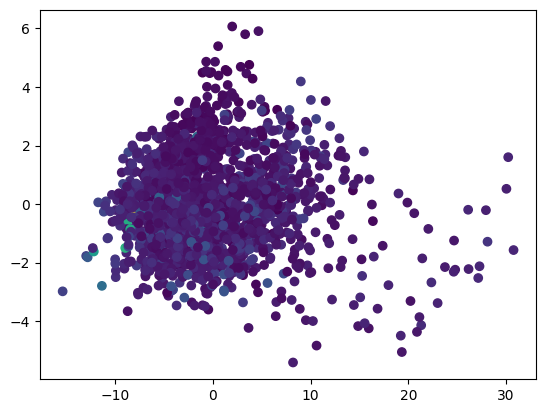

In [44]:
plt.scatter(pt_pca[:,0],pt_pca[:,1],c=pt_gm_price['price'])

In [45]:
# save pca to df
pca_df = pd.DataFrame(pt_pca)
pca_df['lsoa11'] = pt_gm.reset_index()['geo_code'].copy()

In [46]:
pca_df = pca_df.rename(columns={0:'accessibility_PCA1',1:'accessibility_PCA2'})

In [8]:
# 8. School quality
school_quality = pd.read_csv('data/01_raw/School_quality/State_funded_schools_inspections_and_outcomes_as_at_31_August_2024.csv',encoding='ISO-8859-1')

C:\Users\2702471O\AppData\Local\Temp\ipykernel_9148\955227219.py:2: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  school_quality = pd.read_csv('data/01_raw/School_quality/State_funded_schools_inspections_and_outcomes_as_at_31_August_2024.csv',encoding='ISO-8859-1')


In [9]:
# select GM local authorities
school_quality = school_quality[school_quality['Local authority'].isin(['Bolton','Bury', 'Manchester', 'Oldham', 'Rochdale', 'Salford', 'Stockport', 'Tameside', 'Trafford', 'Wigan'])]

In [10]:
school_quality.shape

(1124, 76)

In [49]:
# postcode to lat lon
postcode = pd.read_csv('data/01_raw/postcode_latlon/ukpostcodes.csv',encoding='ISO-8859-1')

In [50]:
# link school to lat lon
school_quality = school_quality.join(postcode.set_index('postcode'),on='Postcode',how='left')

In [51]:
school_quality['id'].isna().sum()

np.int64(1)

In [52]:
school_quality.loc[school_quality['id'].isnull()==1,'latitude'] = 53.54294
school_quality.loc[school_quality['id'].isnull()==1,'longitude'] = -2.128622

In [53]:
# only keep school overall effectiveness, lat, lon, URN, school name, ofsted phase, local authority
school_quality = school_quality[['URN','School name','Ofsted phase','Type of education','Local authority','Overall effectiveness','Postcode','latitude','longitude']]

In [54]:
school_quality_pri_sec = school_quality[school_quality['Ofsted phase'].isin(['Primary','Secondary'])]

In [55]:
# save a copy for geospatial exploration
school_quality.to_csv('data/02_intermediate/state_school_GM.csv')

In [56]:
school_quality_pri_sec.to_csv('data/02_intermediate/state_primary_secondary_school_GM.csv')

## 4.2 Link data

### Visualise neighbourhood data

In [57]:
# Rename lsoa column name for all data to merge
pop_den_lsoa = pop_den_lsoa.rename(columns={'LSOA Code':'lsoa11','Mid-2020 population':'population_2020','Area Sq Km':'lsoa_area','People per Sq Km':'pop_den_2020'})
imd_score = imd_score.rename(columns={'LSOA code (2011)':'lsoa11','Income Score (rate)':'income_score'})

In [58]:
# save neighbourhood data for visualisation
neighs_data = [imd_score[['lsoa11','income_score']],pca_df,pop_den_lsoa[['lsoa11','population_2020','lsoa_area','pop_den_2020']]]
neighs_df = ft.reduce(lambda left, right: pd.merge(left, right, on=['lsoa11'],how='inner'), neighs_data)

In [59]:
gm = gpd.read_file('data/01_raw/Shapefile/GM_lsoa.shp')

In [60]:
gm = gm.join(neighs_df.set_index('lsoa11'),on='code',how='left')

In [61]:
gm.columns

Index(['code', 'name', 'label', 'LA', 'Shape_Leng', 'Shape_Area', 'geometry',
       'income_score', 'accessibility_PCA1', 'accessibility_PCA2',
       'population_2020', 'lsoa_area', 'pop_den_2020'],
      dtype='object')

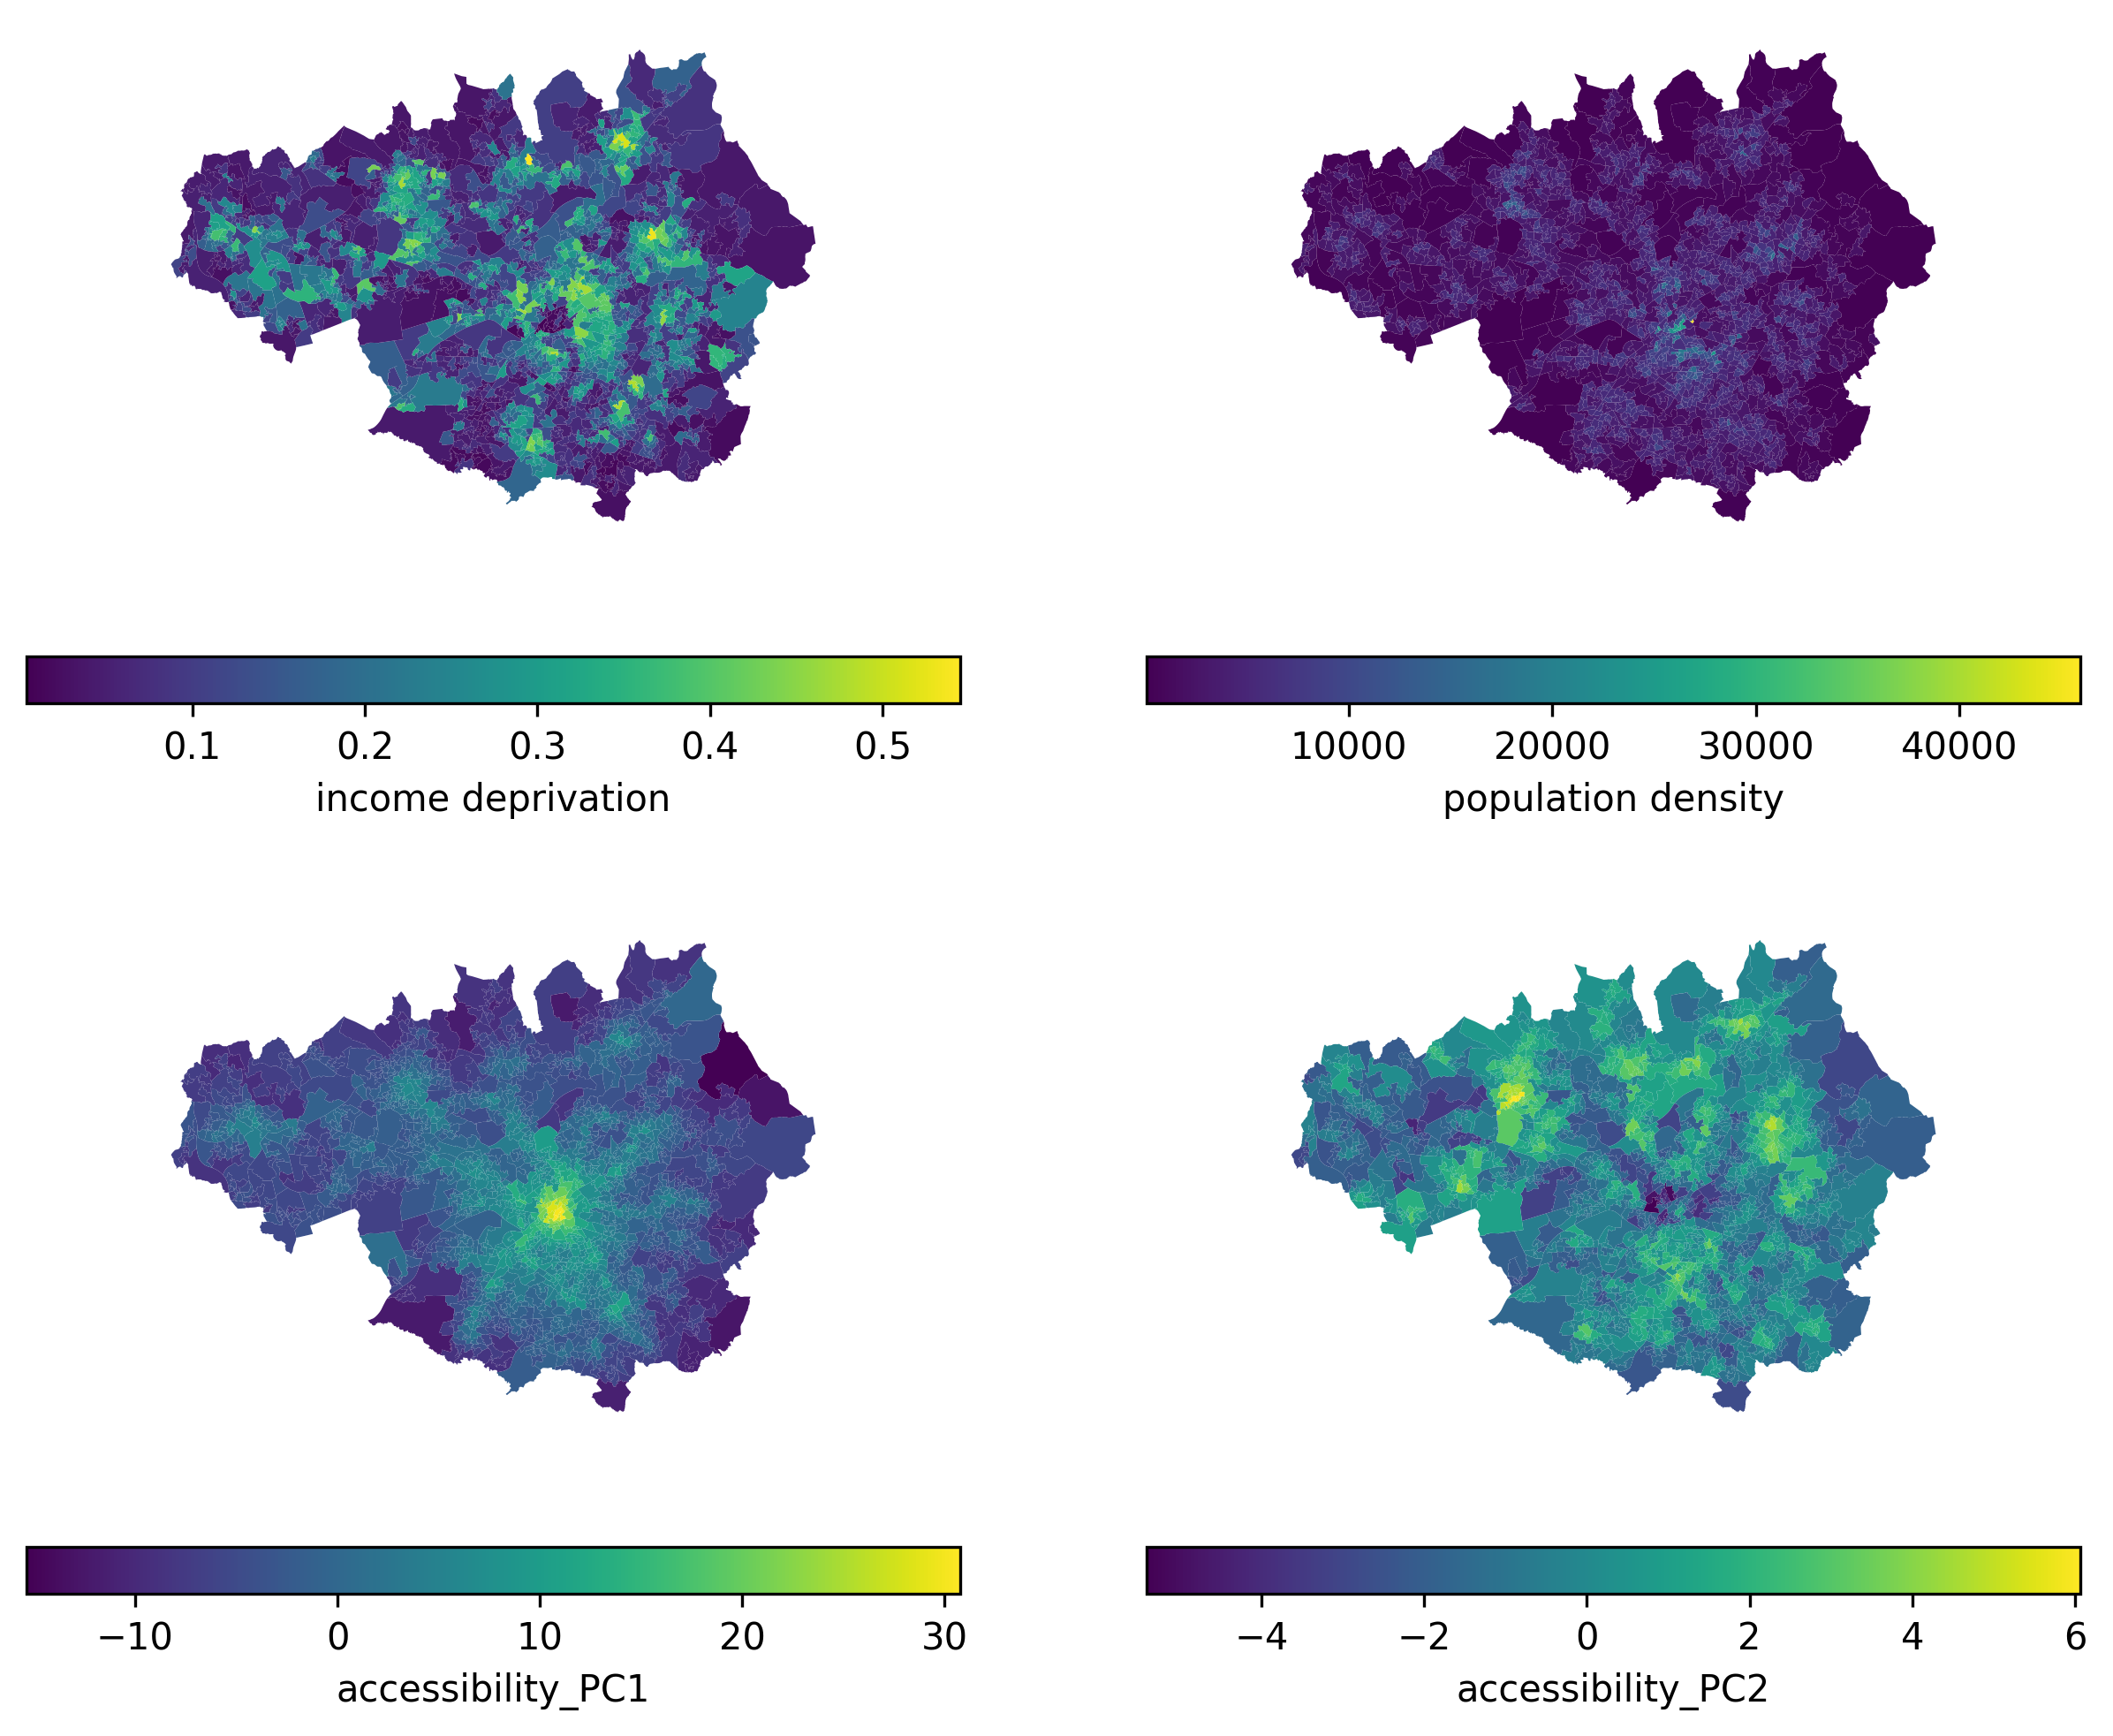

In [62]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(10,8),dpi=300)
gm.plot(column='income_score',ax=ax1,legend=True,
    legend_kwds={"label": "income deprivation", "orientation": "horizontal"})
ax1.set_axis_off()

gm.plot(column='pop_den_2020',ax=ax2,legend=True,
    legend_kwds={"label": "population density", "orientation": "horizontal"})
ax2.set_axis_off()

gm.plot(column='accessibility_PCA1',ax=ax3,legend=True,
    legend_kwds={"label": "accessibility_PC1", "orientation": "horizontal"})
ax3.set_axis_off()

gm.plot(column='accessibility_PCA2',ax=ax4,legend=True,
    legend_kwds={"label": "accessibility_PC2", "orientation": "horizontal"})
ax4.set_axis_off()

### Neighbourhood data

In [63]:
# merge neighbor data to listing
dfs_merge = [listing_epc_val_dedu,imd_score[['lsoa11','income_score']],pca_df,pop_den_lsoa[['lsoa11','population_2020','lsoa_area','pop_den_2020']]]
listing_epc_val_dedu_nei = ft.reduce(lambda left, right: pd.merge(left, right, on=['lsoa11'],how='left'), dfs_merge)

In [64]:
listing_epc_val_dedu_nei[['accessibility_PCA1','accessibility_PCA2','population_2020','lsoa_area','pop_den_2020','income_score']].isna().sum()

accessibility_PCA1    0
accessibility_PCA2    0
population_2020       0
lsoa_area             0
pop_den_2020          0
income_score          0
dtype: int64

### PCA and house price

In [65]:
listing_epc_val_dedu_nei['logprice'] = np.log(listing_epc_val_dedu_nei['price'])

In [66]:
corr = listing_epc_val_dedu_nei[['logprice','accessibility_PCA1','accessibility_PCA2']].corr()

In [67]:
corr

,logprice,accessibility_PCA1,accessibility_PCA2
logprice,1.000000,-0.040249,-0.150592
accessibility_PCA1,-0.040249,1.000000,-0.104357
accessibility_PCA2,-0.150592,-0.104357,1.000000


### Location data

In [68]:
# Lon, lat, x, y
listing_epc_val_dedu_nei_loc = listing_epc_val_dedu_nei.join(uprn.set_index('UPRN'),on='uprn',how='left')

In [69]:
listing_epc_val_dedu_nei_loc[['LATITUDE','LONGITUDE','X_COORDINATE','Y_COORDINATE']].isna().sum()

LATITUDE        4
LONGITUDE       4
X_COORDINATE    4
Y_COORDINATE    4
dtype: int64

In [70]:
# drop na
listing_epc_val_dedu_nei_loc = listing_epc_val_dedu_nei_loc.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

### School quality

In [71]:
listing_school = listing_epc_val_dedu_nei_loc.copy()

In [72]:
# drop school without rating
school_quality_pri_sec = school_quality_pri_sec.dropna(subset=['Overall effectiveness'])

In [73]:
df_la = []
for la in listing_school['nspl_local_authority'].unique():
    house = listing_school[listing_school['nspl_local_authority']==la].reset_index()
    primary = school_quality_pri_sec[(school_quality_pri_sec['Ofsted phase']=='Primary') & (school_quality_pri_sec['Local authority']==la)]
    secondary = school_quality_pri_sec[(school_quality_pri_sec['Ofsted phase']=='Secondary') & (school_quality_pri_sec['Local authority']==la)]

    # Calculate distances between each house and the primary/secondary schools
    primary_distances = cdist(house[['LATITUDE', 'LONGITUDE']].values, primary[['latitude', 'longitude']].values)
    secondary_distances = cdist(house[['LATITUDE', 'LONGITUDE']].values, secondary[['latitude', 'longitude']].values)

    # school with minimum distane
    pri_min_idx = primary_distances.argmin(axis=1)
    sec_min_idx = secondary_distances.argmin(axis=1)

    # join with listing df
    house_pri = house.join(pd.DataFrame(pri_min_idx,columns=['primary_nearest_idx']), how='left')
    house_pri = house_pri.join(primary.reset_index()[['URN','Overall effectiveness']],on='primary_nearest_idx',how='left')

    house_pri_sec = house_pri.join(pd.DataFrame(sec_min_idx,columns=['secondary_nearest_idx']), how='left')
    house_pri_sec = house_pri_sec.join(secondary.reset_index()[['URN','Overall effectiveness']],on='secondary_nearest_idx',how='left',lsuffix='primary',rsuffix='secondary')

    print('{} primary nan: {},secondary nan: {}'.format(la,house_pri_sec['Overall effectivenessprimary'].isna().sum(),house_pri_sec['Overall effectivenesssecondary'].isna().sum()))
    # print('{}: , Max primary school idx: {}, max idx in joined listing: {}'.format(la,primary.reset_index().index.max(),pri_min_idx.max()))
    # print('{}: , Max secondary school idx: {}, max idx in joined listing: {}'.format(la,secondary.reset_index().index.max(),sec_min_idx.max()))
    df_la.append(house_pri_sec)

Bury primary nan: 0,secondary nan: 0
Stockport primary nan: 0,secondary nan: 0
Manchester primary nan: 0,secondary nan: 0
Trafford primary nan: 0,secondary nan: 0
Rochdale primary nan: 0,secondary nan: 0
Bolton primary nan: 0,secondary nan: 0
Oldham primary nan: 0,secondary nan: 0
Salford primary nan: 0,secondary nan: 0
Wigan primary nan: 0,secondary nan: 0
Tameside primary nan: 0,secondary nan: 0


In [74]:
house_pri_sec.shape

(19915, 163)

In [75]:
listing_epc_val_dedu_nei_loc_sch = pd.concat(df_la)

In [76]:
listing_epc_val_dedu_nei_loc_sch.shape, listing_epc_val_dedu_nei_loc_sch['primary_nearest_idx'].isna().sum(), listing_epc_val_dedu_nei_loc_sch['secondary_nearest_idx'].isna().sum()

((216597, 163), np.int64(0), np.int64(0))

In [79]:
listing_epc_val_dedu_nei_loc_sch['Overall effectivenessprimary'] = listing_epc_val_dedu_nei_loc_sch['Overall effectivenessprimary'].map({1:4,2:3,3:2,4:1})
listing_epc_val_dedu_nei_loc_sch['Overall effectivenesssecondary'] = listing_epc_val_dedu_nei_loc_sch['Overall effectivenesssecondary'].map({1:4,2:3,3:2,4:1})

### LSOA school quality

In [77]:
school_quality.head()

,URN,School name,Ofsted phase,Type of education,Local authority,Overall effectiveness,Postcode,latitude,longitude
2152,105144,Grosvenor Nursery School and Day Care Centre,Nursery,LA Nursery School,Bolton,1.0,BL4 8AR,53.547178,-2.388216
2153,105145,The Orchards Nursery School,Nursery,LA Nursery School,Bolton,2.0,BL4 0RA,53.546395,-2.425486
2154,105148,Brandwood Primary School,Primary,Community School,Bolton,2.0,BL3 4BG,53.565839,-2.451802
2155,105149,Brownlow Fold Primary School,Primary,Community School,Bolton,2.0,BL1 3DX,53.589197,-2.440418
2156,105150,Castle Hill Primary School,Primary,Community School,Bolton,2.0,BL2 2JT,53.594700,-2.412569


In [78]:
# link school quality to lsoa
geo_lookup.head()

,pcd,pcd2,pcds,dointr,doterm,usertype,oseast1m,osnrth1m,osgrdind,oa11,cty,ced,laua,ward,hlthau,nhser,ctry,rgn,pcon,eer,teclec,ttwa,pct,itl,park,lsoa11,msoa11,wz11,ccg,bua11,buasd11,ru11ind,oac11,lat,long,lep1,lep2,pfa,imd,calncv,stp
0,AB1 0AA,AB1 0AA,AB1 0AA,198001,199606.0,0,385386.0,801193.0,1,S00090303,S99999999,S99999999,S12000033,S13002843,S08000020,S99999999,S92000003,S99999999,S14000002,S15000001,S09000001,S22000047,S03000012,S30000026,S99999999,S01006514,S02001237,S34002990,S03000012,S99999999,S99999999,3.0,1C3,57.101474,-2.242851,S99999999,S99999999,S23000009,6715,S99999999,S99999999
1,AB1 0AB,AB1 0AB,AB1 0AB,198001,199606.0,0,385177.0,801314.0,1,S00090303,S99999999,S99999999,S12000033,S13002843,S08000020,S99999999,S92000003,S99999999,S14000002,S15000001,S09000001,S22000047,S03000012,S30000026,S99999999,S01006514,S02001237,S34002990,S03000012,S99999999,S99999999,3.0,1C3,57.102554,-2.246308,S99999999,S99999999,S23000009,6715,S99999999,S99999999
2,AB1 0AD,AB1 0AD,AB1 0AD,198001,199606.0,0,385053.0,801092.0,1,S00090399,S99999999,S99999999,S12000033,S13002843,S08000020,S99999999,S92000003,S99999999,S14000002,S15000001,S09000001,S22000047,S03000012,S30000026,S99999999,S01006514,S02001237,S34003015,S03000012,S99999999,S99999999,3.0,6A1,57.100556,-2.248342,S99999999,S99999999,S23000009,6715,S99999999,S99999999
3,AB1 0AE,AB1 0AE,AB1 0AE,199402,199606.0,0,384600.0,799300.0,8,S00091322,S99999999,S99999999,S12000034,S13002864,S08000020,S99999999,S92000003,S99999999,S14000058,S15000001,S09000001,S22000047,S03000013,S30000027,S99999999,S01006853,S02001296,S34003292,S03000013,S99999999,S99999999,6.0,1A2,57.084444,-2.255708,S99999999,S99999999,S23000009,5069,S99999999,S99999999
4,AB1 0AF,AB1 0AF,AB1 0AF,199012,199207.0,1,384460.0,800660.0,8,S00090299,S99999999,S99999999,S12000033,S13002843,S08000020,S99999999,S92000003,S99999999,S14000002,S15000001,S09000001,S22000047,S03000012,S30000026,S99999999,S01006511,S02001236,S34003015,S03000012,S99999999,S99999999,3.0,6A4,57.096656,-2.258102,S99999999,S99999999,S23000009,6253,S99999999,S99999999


In [79]:
geo_lookup['pcd'] = geo_lookup['pcd'].str.replace(" ", "")
school_quality['Postcode'] = school_quality['Postcode'].str.replace(" ", "")

In [80]:
school_quality_lsoa = school_quality.join(geo_lookup[['pcd','lsoa11','msoa11']].set_index('pcd'),on='Postcode',how='left')

In [81]:
school_quality_lsoa['lsoa11'].isna().sum()

np.int64(1)

In [82]:
school_quality_lsoa[school_quality_lsoa['lsoa11'].isna()]

,URN,School name,Ofsted phase,Type of education,Local authority,Overall effectiveness,Postcode,latitude,longitude,lsoa11,msoa11
20919,149080,Woodford Primary School,Primary,Free School,Stockport,NaN,SK71GX,53.339604,-2.156663,NaN,NaN


In [83]:
# compute neighbourhood level school quality
lsoa_school = school_quality_lsoa.groupby(['lsoa11'])['Overall effectiveness'].mean().reset_index()

In [84]:
lsoa_school.head()

,lsoa11,Overall effectiveness
0,E01004767,1.0
1,E01004769,2.0
2,E01004770,2.0
3,E01004771,2.0
4,E01004774,2.0


In [85]:
# link lsoa school quality to gm geometry
gm = gm.join(lsoa_school.set_index('lsoa11'),on='code',how='left')

In [86]:
gm['Overall effectiveness'].isna().sum()

np.int64(857)

In [87]:
# replace null rating as '5'
gm['Overall effectiveness'].fillna(5.0, inplace = True)

C:\Users\2702471O\AppData\Local\Temp\ipykernel_14276\2859488581.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gm['Overall effectiveness'].fillna(5.0, inplace = True)


In [ ]:
# # link lsoa school quality to house dataset
# listing_epc_imd_ac_pop_latlon_sch_lsoa = listing_epc_imd_ac_pop_latlon_sch.join(lsoa_school.set_index('lsoa11'),on='lsoa11',how='left')

NameError: name 'listing_epc_imd_ac_pop_latlon_sch' is not defined

In [ ]:
# listing_epc_imd_ac_pop_latlon_sch_lsoa = listing_epc_imd_ac_pop_latlon_sch_lsoa.rename(columns={'Overall effectiveness':'School_quality_lsoa'})

In [ ]:
# listing_epc_imd_ac_pop_latlon_sch_lsoa['School_quality'].value_counts()

School_quality
2.000000    104363
1.666667     51927
2.333333     35006
1.333333     10542
2.666667      9435
3.000000      2449
1.000000      1854
3.333333       437
1.500000       328
2.500000       256
Name: count, dtype: int64

In [ ]:
# listing_epc_imd_ac_pop_latlon_sch_lsoa['School_quality_lsoa'].value_counts()

School_quality_lsoa
2.000000    74626
1.000000    10613
3.000000     7703
1.500000     5204
2.500000     3747
1.666667     1706
4.000000      877
2.333333      769
3.500000      287
1.333333      243
1.750000       96
2.666667       84
3.333333       67
2.200000       19
Name: count, dtype: int64

# 5. Save data

In [81]:
listing_epc_neighbourhood = listing_epc_val_dedu_nei_loc_sch.copy()

In [82]:
listing_epc_neighbourhood.shape

(216597, 163)

In [83]:
listing_epc_neighbourhood.to_csv('data/03_linked/enriched_listing.csv', chunksize=10000)